## Using ML and neural network on physical exercise dataset to predict peoples age

In [274]:
import pandas as pd
import matplotlib.pyplot as plt

In [275]:
# load data
df_raw = pd.read_csv('gym_members_exercise_tracking.csv')

In [276]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    object 
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    object 
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int

No missing values :)
lets do one hot encoding on gender and workout type

In [277]:
df = pd.get_dummies(df_raw, columns=df_raw.select_dtypes(include=['object']).columns, dtype='int', drop_first=True)

In [278]:
df

,Age,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Gender_Male,Workout_Type_HIIT,Workout_Type_Strength,Workout_Type_Yoga
0,56,88.3,1.71,180,157,60,1.69,1313.0,12.6,3.5,4,3,30.20,1,0,0,1
1,46,74.9,1.53,179,151,66,1.30,883.0,33.9,2.1,4,2,32.00,0,1,0,0
2,32,68.1,1.66,167,122,54,1.11,677.0,33.4,2.3,4,2,24.71,0,0,0,0
3,25,53.2,1.70,190,164,56,0.59,532.0,28.8,2.1,3,1,18.41,1,0,1,0
4,38,46.1,1.79,188,158,68,0.64,556.0,29.2,2.8,3,1,14.39,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,87.1,1.74,187,158,67,1.57,1364.0,10.0,3.5,4,3,28.77,1,0,1,0
969,25,66.6,1.61,184,166,56,1.38,1260.0,25.0,3.0,2,1,25.69,1,0,1,0
970,59,60.4,1.76,194,120,53,1.72,929.0,18.8,2.7,5,3,19.50,0,0,0,0
971,32,126.4,1.83,198,146,62,1.10,883.0,28.2,2.1,3,2,37.74,1,1,0,0


Split and scale the data

In [279]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [280]:
# features and target
y = df['Age']   
X = df.drop('Age',axis=1)

# scale
scaler = StandardScaler()
X = scaler.fit_transform(X)

# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


I will try to predict a persons age by using their workout-data (training data heheh)

# Random Forest regressor

In [281]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize model
model = RandomForestRegressor(random_state=42, n_estimators=150)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 129.0910621082621
R² Score: 0.1409418220705957


In [282]:
abs(y_test - y_pred).mean()

np.float64(9.52625641025641)

we were on average off by 9.5 years

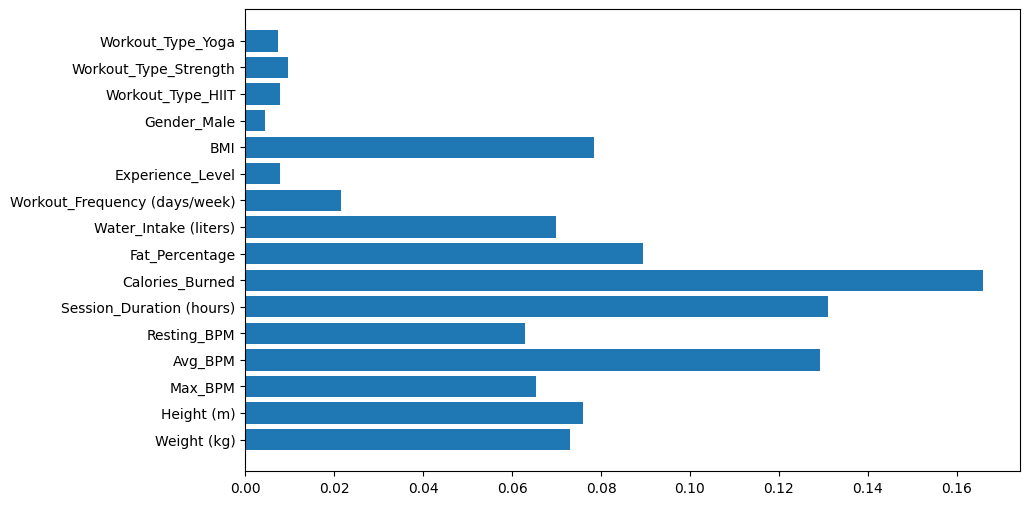

In [283]:


plt.figure(figsize=(10, 6))
plt.barh(df.drop(['Age'], axis=1).columns, model.feature_importances_)
plt.show()

This graph shows the most important variables, workout type not very important compared to cals burned, session duration and BPM

# Neural Network

In [284]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout


In [285]:
# Build the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dense(1)  # Output layer for regression
])

C:\Users\jonas\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [293]:

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

# Evaluate the model
test_loss, test_mae = model.evaluate(X_test, y_test)
print(f"Test MAE: {test_mae}")

# Make predictions
predictions = model.predict(X_test)

Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 60.3377 - mae: 6.1938 - val_loss: 76.1979 - val_mae: 7.1827
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 54.7364 - mae: 6.0774 - val_loss: 75.2639 - val_mae: 7.1020
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 55.0639 - mae: 6.0047 - val_loss: 75.8893 - val_mae: 7.0871
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 52.9194 - mae: 5.9748 - val_loss: 78.3064 - val_mae: 7.1215
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 54.9487 - mae: 6.0345 - val_loss: 73.7942 - val_mae: 7.0126
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 54.8343 - mae: 5.9379 - val_loss: 74.2399 - val_mae: 7.0365
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 43.2277 - mae: 5.1924 - val_loss: 73.0973 - val_mae: 6.9239
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 53.0885 - mae: 5.9945 - val_loss: 71.4356 - val_mae: 6.9459
Epoch 9/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - los

MAE = 6.1 means we were on average off by 6.1 years which I think is a good improvement from Random Forest

Lets look at the perdictions the neural network makes

First, the predictions on the test set

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


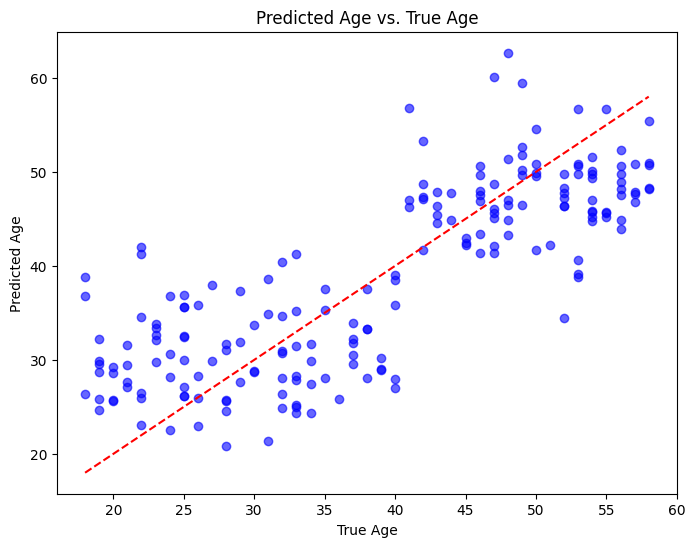

In [294]:
y_pred = model.predict(X_test)

# scatter plot of predicted vs. real age
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)

plt.title("Predicted Age vs. True Age")
plt.xlabel("True Age")
plt.ylabel("Predicted Age")

# ideal prediction line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')

plt.show()

Predictions on the training set

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 815us/step


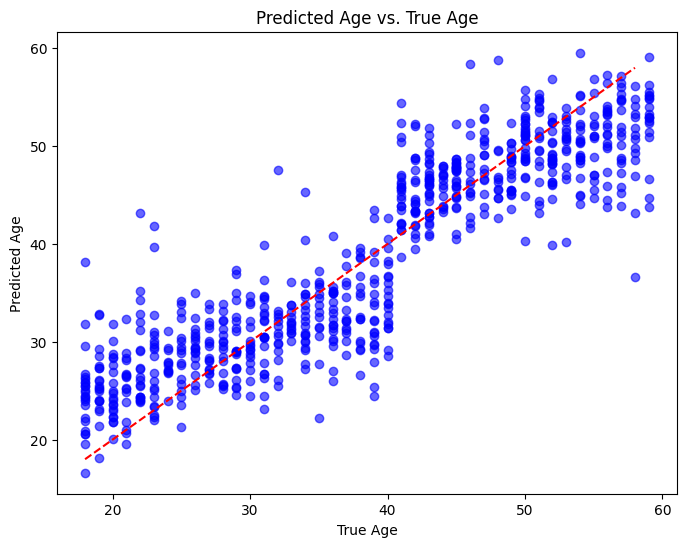

In [295]:
y_pred_train = model.predict(X_train)

# scatter plot of predicted vs. real age
plt.figure(figsize=(8, 6))
plt.scatter(y_train, y_pred_train, color='blue', alpha=0.6)

plt.title("Predicted Age vs. True Age")
plt.xlabel("True Age")
plt.ylabel("Predicted Age")

# ideal prediction line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')

plt.show()
